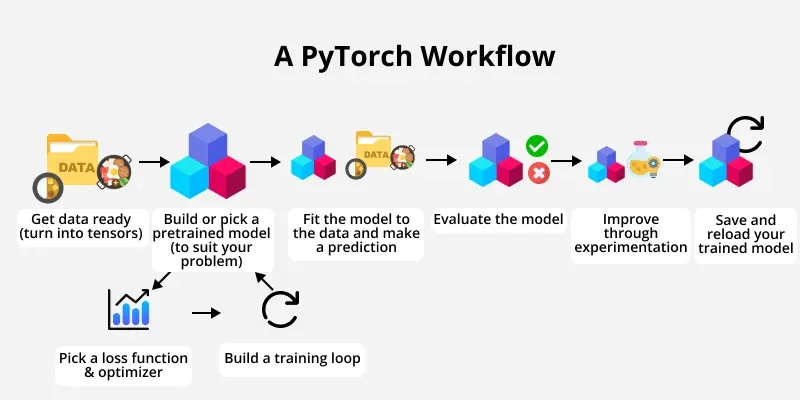

In [1]:
import torch 
from torch import nn
import matplotlib.pyplot as plt

### Creating and Splitting Data

- `x = torch.arange(0, 1, 0.02)` creates input values from `0` to `1`.
- `y = weight * x + bias` creates the target values using a simple linear equation.
- The data is split into **80% training data** and **20% testing data**.
- `plot_prediction()` is used to visualize the training data, testing data, and model predictions.

In [2]:
weight=0.7
bias=0.3
x=torch.arange(0,1,0.02)
y=weight*x +bias
x.shape , y.shape

(torch.Size([50]), torch.Size([50]))

In [3]:
x[:5] , y[:5]

(tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800]),
 tensor([0.3000, 0.3140, 0.3280, 0.3420, 0.3560]))

In [4]:
train_split=int(0.8*len(x))
x_train , x_test =x[:train_split],x[train_split:]
y_train , y_test =y[:train_split],y[train_split:]
len(x_train),len(x_test),len(y_train),len(y_test)


(40, 10, 40, 10)

In [5]:
def plot_prediction(train_data=x_train,train_labels=y_train,test_data=x_test,test_labels=y_test,predictions=None):
    plt.figure(figsize=(10,7))
    #plot the training data
    plt.scatter(train_data, train_labels,c='b',s=4,label='Training data')
    #plot the testing data
    plt.scatter(test_data,test_labels,c='g',s=4,label='Testing data')

    # if i have a prediction
    if predictions is not None:
        plt.scatter(test_data,predictions,c='r',s=4, label='Predictions')

    # show the legend
    plt.legend(prop={"size":14})

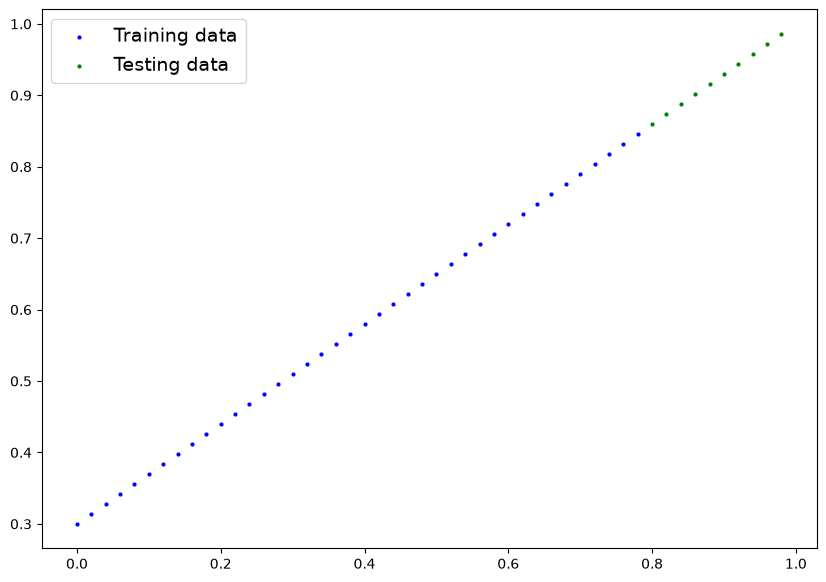

In [6]:
plot_prediction()

### PyTorch Model: Inheritance vs Composition

- `nn` is a PyTorch module that contains many classes, such as `Module`, `Parameter`, and `Linear`.
- `nn.Module` is the **base class for PyTorch models**. We inherit from it because our `LinearRegressionModel` **is a Module**.
- `nn.Parameter` is used **inside** the model because the model **has trainable parameters** (`weight` and `bias`). We do not inherit from `Parameter`.
- `nn.Linear` can also be used inside a model without inheriting from it. In short: **Inheritance = IS-A**, **Composition = HAS-A**.

### `LinearRegressionModel`

- `class LinearRegressionModel(nn.Module)` → Creates a model that inherits the features of `nn.Module`.
- `super().__init__()` → Initializes the parent `nn.Module`.
- `nn.Parameter(...)` → Creates trainable `weight` and `bias` parameters.
- `requires_grad=True` → Allows PyTorch to calculate gradients for these parameters during training.
- `forward()` → Defines how the input moves through the model: `y = weight * x + bias`.
- `torch.manual_seed(42)` → Makes random values reproducible.
- `model_0.parameters()` → Returns the trainable parameters of the model.
- `model_0.state_dict()` → Returns the model's parameters (`weight` and `bias`) with their current values.

In [7]:
class LinearRegressionModel(nn.Module,nn.Parameter):
    def __init__(self):
        super(LinearRegressionModel,self).__init__()
        self.weight=nn.Parameter(torch.rand(1,dtype=torch.float),requires_grad=True)
        self.bias=nn.Parameter(torch.rand(1,dtype=torch.float),requires_grad=True)
        
    def forward(self,x : torch.Tensor) -> torch.Tensor:
        return self.weight * x +self.bias


In [8]:
torch.manual_seed(42)
model_0=LinearRegressionModel()

In [9]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [10]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [11]:
with torch.inference_mode():
    y_preds=model_0.forward(x_test)
print(y_preds)

tensor([1.6208, 1.6385, 1.6561, 1.6738, 1.6914, 1.7090, 1.7267, 1.7443, 1.7620,
        1.7796])


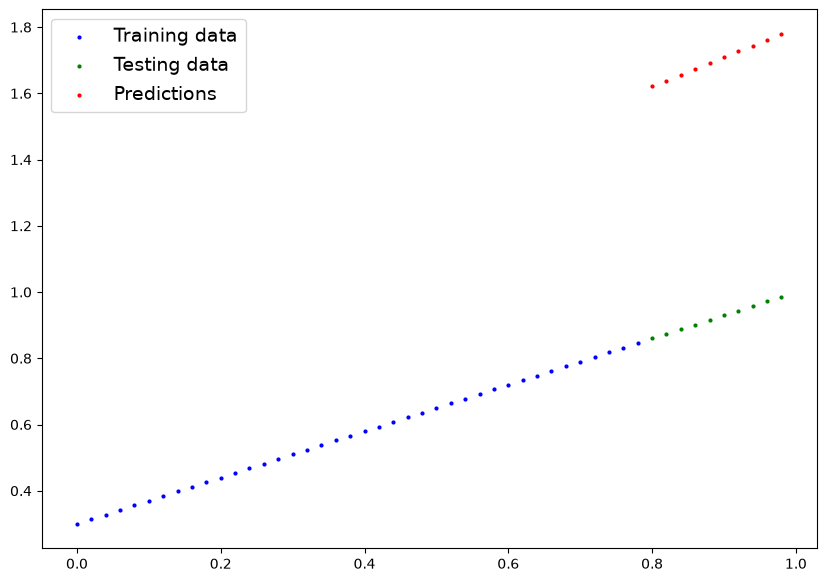

In [12]:
plot_prediction(predictions=y_preds)

### Loss Function and Optimizer

- `loss_fn = nn.L1Loss()` creates the **L1 Loss function**, which measures the difference between the model's predictions and the true values.
- `optimizer = torch.optim.SGD(...)` creates an **SGD optimizer** to update the model's parameters during training.
- `params=model_0.parameters()` tells the optimizer which parameters it should update, such as `weight` and `bias`.
- `lr=0.01` is the **learning rate**, which controls how large each parameter update is.

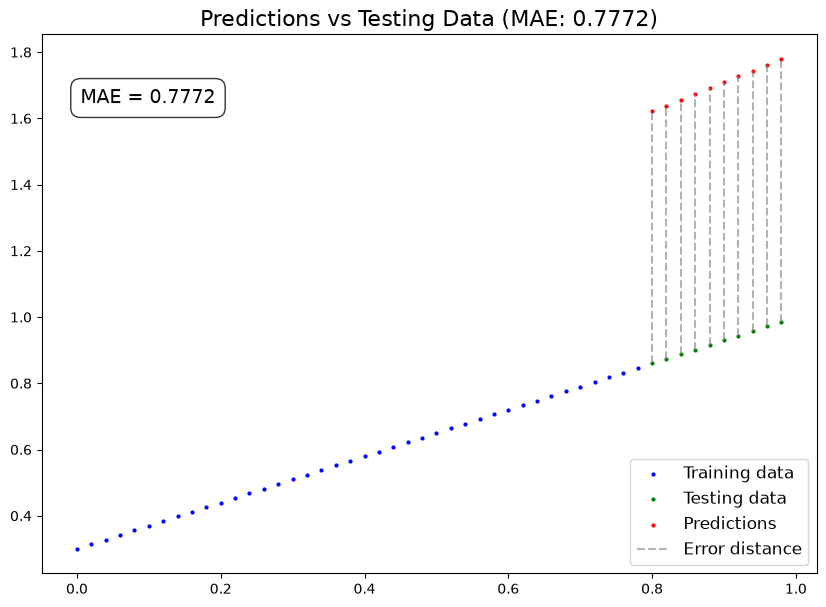

In [13]:
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.01)

PyTorch training loop and Testing loop

For the training loop, we'll build the following steps:

1. Forward pass
2. Calculate the loss
3. Zero gradients
4. Perform backpropagation on the loss
5. Update the optimizer (gradient descent)

In [14]:
torch.manual_seed(42)
epochs=100
#create some lists to track results 
train_loss_values=[]
test_loss_values=[]
epoch_count=[]
for epoch in range(epochs):
    #training 
    model_0.train()
    # 1. Forward pass
    y_pred=model_0.forward(x_train)
    # 2. Calculate the loss
    loss=loss_fn(y_pred,y_train)
    # 3. Zero gradients
    optimizer.zero_grad()
    # 4. Perform backpropagation on the loss
    loss.backward()
    # 5. Update the optimizer (gradient descent)
    optimizer.step()

    #testing 
    #put the model in the evaluation mode
    model_0.eval()
    with torch.inference_mode():
        test_pred=model_0.forward(x_test)
        test_loss=loss_fn(test_pred,y_test)
    #print what is going on 
    if epoch  % 10==0:
        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().numpy())
        test_loss_values.append(test_loss.detach().numpy())
        print(f"Epoch : {epoch} | MAE Train loss : {loss} | MAE Testing loss : {test_loss}")



Epoch : 0 | MAE Train loss : 0.6860889196395874 | MAE Testing loss : 0.7637526988983154
Epoch : 10 | MAE Train loss : 0.5708791017532349 | MAE Testing loss : 0.6290428042411804
Epoch : 20 | MAE Train loss : 0.45566922426223755 | MAE Testing loss : 0.4943329691886902
Epoch : 30 | MAE Train loss : 0.34045934677124023 | MAE Testing loss : 0.35962313413619995
Epoch : 40 | MAE Train loss : 0.2252494841814041 | MAE Testing loss : 0.2249133139848709
Epoch : 50 | MAE Train loss : 0.1100396141409874 | MAE Testing loss : 0.09020347893238068
Epoch : 60 | MAE Train loss : 0.009724985808134079 | MAE Testing loss : 0.020998019725084305
Epoch : 70 | MAE Train loss : 0.006216754671186209 | MAE Testing loss : 0.014099234715104103
Epoch : 80 | MAE Train loss : 0.002788322512060404 | MAE Testing loss : 0.005826681852340698
Epoch : 90 | MAE Train loss : 0.007095950655639172 | MAE Testing loss : 0.00754010071977973


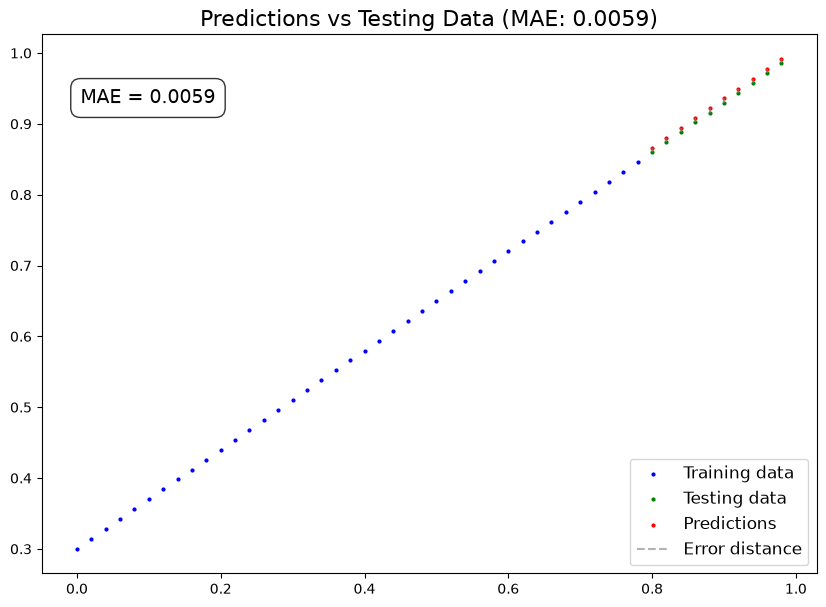

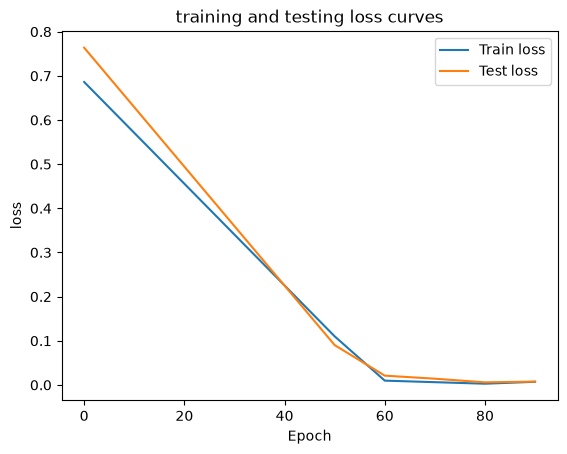

In [15]:
plt.plot(epoch_count,train_loss_values,label="Train loss")
plt.plot(epoch_count,test_loss_values,label="Test loss")
plt.title("training and testing loss curves")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()